In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, NNConv, CGConv, global_max_pool, GCNConv, GATConv, GATv2Conv

from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN, CrystalNN, VoronoiNN
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

import graphy_gnn

## Data Prep

In [2]:
if not os.path.exists(f"Final_Dataset/gnn graphs/train_graphs.pt"):
    comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")

    comb_df = comb_df[comb_df["defect_sites"] != 1]
    
    # Split the data
    train_set, test_set = train_test_split(comb_df, test_size=0.2, stratify=comb_df['strata'], random_state=42)
    test_set, val_set = train_test_split(test_set, test_size=0.5, random_state=42)

    # Create graphs for each set
    train_graphs = graphy_gnn.fast_grapy(train_set)
    val_graphs = graphy_gnn.fast_grapy(val_set)
    test_graphs = graphy_gnn.fast_grapy(test_set)

    # Save graphs
    torch.save(train_graphs, "Final_Dataset/gnn graphs/train_graphs.pt")
    torch.save(val_graphs, "Final_Dataset/gnn graphs/val_graphs.pt")
    torch.save(test_graphs, "Final_Dataset/gnn graphs/test_graphs.pt")

else:
    train_graphs = torch.load("Final_Dataset/gnn graphs/train_graphs.pt", weights_only=False)
    val_graphs = torch.load("Final_Dataset/gnn graphs/val_graphs.pt", weights_only=False)
    test_graphs = torch.load("Final_Dataset/gnn graphs/test_graphs.pt", weights_only=False)

In [3]:
# Find the graph where the edge features has shape 0 and remove them

def remove_1_defect_graphs(graphs):
    unwanted = []
    for i, data in enumerate(graphs):
        if data.edge_attr.shape[0] == 0:
            unwanted.append(i)

    new_graphs = [data for i, data in enumerate(graphs) if i not in unwanted]
    return new_graphs

new_train_graphs = remove_1_defect_graphs(train_graphs)
new_val_graphs = remove_1_defect_graphs(val_graphs)
new_test_graphs = remove_1_defect_graphs(test_graphs)

In [4]:
mean_en = []
idss = []

look_dict = {
    "GaSe": ["In", "S"],
    "InSe": ["Ga", "S"],
    "BN"  : ["C"],
    "P"   : ["N"],
    "WSe2": ["Mo", "S"],
    "MoS2": ["W", "Se"],
    }

for i in look_dict.keys():
    pristine_sample = Structure.from_file(f"Final_Dataset/ref_cifs/high_{i}.cif")
    sample_elements = pristine_sample.composition.elements

    sample_X = [e.X for e in sample_elements]

    sample_en_mean = float(np.round(np.mean(sample_X), 2))
    mean_en.append(sample_en_mean)

    # Get Ids
    possible_elements = look_dict.get(i)
    the_ids = [Element(el).Z for el in possible_elements]
    idss.append([0] + the_ids)

look_up_dict = dict(zip(mean_en, idss))

def get_ids_ratios(graphs):
    for data in graphs:

        # Host average electronegativity
        host_avg_en = np.round(torch.round(data.u[..., 2], decimals=2).item(), 2)
        # idx+=1
        # print(idx)
        # print(host_avg_en)

        ids = look_up_dict.get(host_avg_en)
        # print(ids)

        # Defect types
        defects = data.x[:, 6].cpu().numpy()

        # Count occurrences of each id
        num_defects = [np.sum(defects == item) for item in ids]

        total = sum(num_defects)

        ratios = [count / total for count in num_defects]

        data.ids=torch.tensor(ids, dtype=torch.long)
        data.ratios=torch.tensor(ratios, dtype=torch.float)

    return graphs

new_train_graphs = get_ids_ratios(new_train_graphs)
new_val_graphs = get_ids_ratios(new_val_graphs)
new_test_graphs = get_ids_ratios(new_test_graphs)

/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 32 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 24 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/amutua/inverse/lib/python3.10/site-packages/pymatgen/core/structure.py:3109: UserWarning: Issues encountered while parsing CIF: 48 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


Band Gap Distribution in the Data
Counts per bin: [ 439 2673 1542 1098  350  257  244  284 1938 1684   23   28   24 1272
   18    2    2    3    4]
Bin boundaries: [0.         0.13157895 0.26315789 0.39473684 0.52631579 0.65789474
 0.78947368 0.92105263 1.05263158 1.18421053 1.31578947 1.44736842
 1.57894737 1.71052632 1.84210526 1.97368421 2.10526316 2.23684211
 2.36842105 2.5       ]


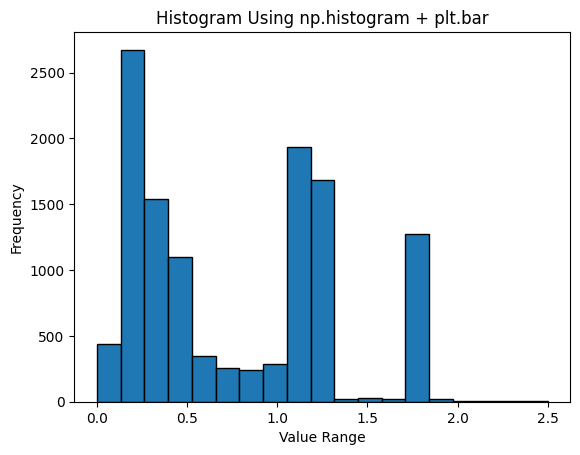

In [5]:
# Sample_train_graphs
def get_bg_distribution(the_graphs, bins_num):
    print("Band Gap Distribution in the Data")
    train_targets = [the_graphs[i].y.item() for i in range(len(the_graphs))]

    boundaries = np.linspace(0, 2.5, bins_num)

    hist, bin_edges = np.histogram(train_targets, bins=boundaries)

    # frequency per bin
    # freq = hist + 1e-6

    # inverse frequency weights
    # bin_weights = 1.0 / np.sqrt(freq)
    # bin_weights = np.clip(1.0 / freq, a_min=None, a_max=np.percentile(1.0/freq, 90))



    print("Counts per bin:", hist)
    print("Bin boundaries:", bin_edges)

    # print(dict(zip(bin_edges, hist)))

    # 2. Graphically plot the computed data
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="black", align="edge")
    plt.title("Histogram Using np.histogram + plt.bar")
    plt.xlabel("Value Range")
    plt.ylabel("Frequency")
    plt.show()

get_bg_distribution(new_train_graphs, 20)

In [ ]:
# 2. Get counts and identify valid bins (e.g., threshold of 2 instead of 10 for this sample)
counts, edges = np.histogram(data, bins=bin_edges)
threshold = 30
valid_bin_indices = np.where(hist >= threshold)[0]

# 3. Find which bin index each data point belongs to
# np.digitize returns 1-indexed values, subtract 1 to match np.histogram indices
bin_indices = np.digitize(data, bin_edges) - 1

# 4. Handle edge case: clip the maximum value so it maps to the last bin
bin_indices = np.clip(bin_indices, 0, len(counts) - 1)

# 5. Filter the original array
filtered_data = data[np.isin(bin_indices, valid_bin_indices)]

Band Gap Distribution in the Data
Counts per bin: [ 439 2673 1542 1098  350  257  244  284 1938 1684   20    0    0   17
    0    0    0    0    0]
Bin boundaries: [0.         0.13157895 0.26315789 0.39473684 0.52631579 0.65789474
 0.78947368 0.92105263 1.05263158 1.18421053 1.31578947 1.44736842
 1.57894737 1.71052632 1.84210526 1.97368421 2.10526316 2.23684211
 2.36842105 2.5       ]


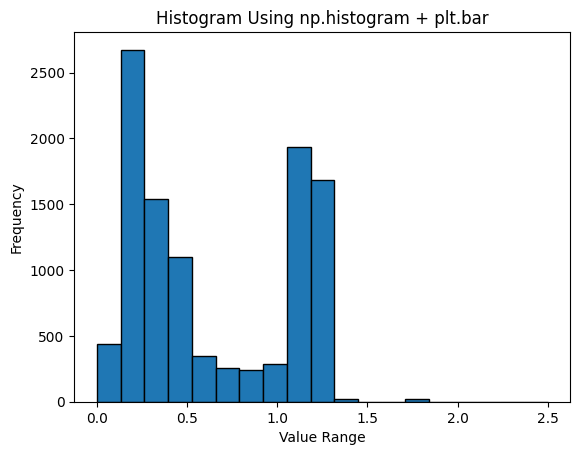

In [6]:
# Remove unwanted graphs

def remove_unwanted_bgvs(graphs):
    new_graphs = []
    for data in graphs:
        focus_bgv = data.y.numpy()[0]
        if focus_bgv < 1.8:
            if focus_bgv < 1.4 or focus_bgv > 1.7:
                new_graphs.append(data)

    return new_graphs

new_train_graphs = remove_unwanted_bgvs(new_train_graphs)
new_val_graphs = remove_unwanted_bgvs(new_val_graphs)
new_test_graphs = remove_unwanted_bgvs(new_test_graphs)

# test_graphs = remove_unwanted_bgvs(new_train_graphs)
get_bg_distribution(new_train_graphs,20)

In [ ]:
train_loader = DataLoader(new_train_graphs, batch_size=1, shuffle=True)
val_loader = DataLoader(new_val_graphs, batch_size=1, shuffle=False)
test_loader = DataLoader(new_test_graphs, batch_size=1, shuffle=False)

In [29]:
# Use data size to determine model architecture
NODE_DIM =train_graphs[0].x.shape[1] # 27
EDGE_DIM =train_graphs[0].edge_attr.shape[1] # 14
HIDDEN_DIM = 128
EMBED_DIM = 64
U_DIM =train_graphs[0].u.shape[1] # 14

# The GNN Model

In [30]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from tqdm.auto import tqdm

def evaluate(model, loader, loss_fn, device):
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for data in tqdm(loader, leave=False):
            data = data.to(device)
            out = model(data)
            loss = loss_fn(out, data.y)

            eval_loss += loss.item() * data.num_graphs
    return eval_loss / len(loader.dataset)

def train(model, train_loader, loss_fn, device, optimizer):
    model.train()
    train_loss = 0


    for data in tqdm(train_loader, leave=False):
        optimizer.zero_grad()

        data = data.to(device)
        out = model(data)
        loss = loss_fn(out, data.y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()
        train_loss += loss.item() * data.num_graphs

    return train_loss / len(train_loader.dataset)

def predict(model, loader, device, visualize=False):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for data in tqdm(loader, leave=False):
            data = data.to(device)
            out = model(data)

            if data.y:
                actuals.append(data.y.cpu().numpy())

            predictions.append(out.cpu().numpy())

    prediction = np.concatenate(predictions, axis=0).flatten()
    actual = np.concatenate(actuals, axis=0).flatten()

    if visualize:
        fig, axs = plt.subplots(3, 1, figsize=(10, 15))

        # model values
        predicted_values = prediction
        actual_values = actual
        residuals = actual_values - predicted_values


        axs[0].scatter(actual_values, predicted_values )
        axs[0].plot(actual_values, actual_values, c="black")
        axs[0].set_xlabel('Actual Band Gaps(eV)')
        axs[0].set_ylabel('Predicted Band Gaps(eV)')
        axs[0].set_title('Actual vs Predicted Band Gap Values')
        axs[0].legend()

        axs[1].plot(actual_values[100:150], label='Actual Values', marker='o')
        axs[1].plot(predicted_values[100:150], label='Predicted Values', marker='o')
        axs[1].set_xlabel('Samples')
        axs[1].set_ylabel('Band gap(eV)')
        axs[1].set_title('Actual vs Predicted Band Gap Values')
        axs[1].legend()

        axs[2].scatter(predicted_values, residuals )
        axs[2].axhline(0, color='red', linestyle='--')
        axs[2].set_xlabel('Predicted Band Gaps(eV)')
        axs[2].set_ylabel('Residuals (Actual - Predicted)')
        axs[2].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

    return prediction, actual

In [31]:
# Loss functions

class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        ey_t = input-target
        return torch.mean(torch.log(torch.cosh(ey_t + 1e-12)))


class RelativeMSELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        return torch.mean(((y_pred-y_true)/ (y_true + 1e-8)) ** 2)


class SMAPELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        numerator = torch.abs(y_pred - y_true)
        denominator = (torch.abs(y_true) + torch.abs(y_pred))/2.0 + 1e-8
        return torch.mean(numerator/denominator)

class RelativeWeightedLoss(nn.Module):
    def __init__(self, delta=0.1, lambda_rel=0.3, eps=1e-2, alpha=1.5):
        super().__init__()
        self.delta = delta
        self.lambda_rel = lambda_rel  # weight of relative term
        self.eps = eps                # prevents div-by-zero for ~0 targets
        self.alpha = alpha

    def forward(self, input, target):
        error = input - target
        abs_error = torch.abs(error)

        # Huber absolute loss
        huber = torch.where(
            abs_error < self.delta,
            0.5 * error ** 2,
            self.delta * (abs_error - 0.5 * self.delta)
        )

        # Relative error: penalizes proportional misses
        relative = abs_error / (torch.abs(target) + self.eps)
        to_return = torch.mean(huber + self.lambda_rel * relative)

        # weights = (1.0 + target) ** self.alpha
        # weighted = weights * huber 
        # to_return = torch.mean(weighted)

        return to_return

# loss_fn = nn.MSELoss()
# loss_fn = LogCoshLoss()
# loss_fn = RelativeWeightedLoss()
# loss_fn = RelativeMSELoss()
# loss_fn = SMAPELoss()

In [ ]:
# Train model
'''

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = loss_fn(out, data.y)

            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def train(model, train_loader, val_loader, epochs, optimizer, loss_fn):
    train_losses = []
    val_losses = []

    # Learning rate scheduler to help convergence
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            out = model(data)
            loss = loss_fn(out, data.y)

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
        train_loss = total_loss / len(train_loader.dataset)
        # train_loss = train(the_model, train_loader, optimizer, loss_fn)
        val_loss = evaluate(model, val_loader, loss_fn)
        scheduler.step()

        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    # Test model
    test_loss = evaluate(model, test_loader, loss_fn)
    print(f'Test Loss: {test_loss:.4f}')

    return train_losses, val_losses

def predict(model, loader, actuals=False):
    model.eval()
    if actuals:
        predictions = []
        actual = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())
                actual.append(data.y.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        actual = np.concatenate(actual, axis=0).flatten()
        return predictions, actual
    else:
        predictions = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        return predictions

# Informative Graphs
def get_graphs(train_losses, val_losses, the_model):
    fig, axs = plt.subplots(3, 1, figsize=(10, 15))

    # model values
    predicted_values, actual_values = predict(the_model, test_loader, actuals=True)
    residuals = actual_values - predicted_values


    axs[0].scatter(actual_values, predicted_values )
    axs[0].plot(actual_values, actual_values, c="black")
    axs[0].set_xlabel('Actual Band Gaps(eV)')
    axs[0].set_ylabel('Predicted Band Gaps(eV)')
    axs[0].set_title('Actual vs Predicted Band Gap Values')
    axs[0].legend()

    axs[1].plot(actual_values[100:150], label='Actual Values', marker='o')
    axs[1].plot(predicted_values[100:150], label='Predicted Values', marker='o')
    axs[1].set_xlabel('Samples')
    axs[1].set_ylabel('Band gap(eV)')
    axs[1].set_title('Actual vs Predicted Band Gap Values')
    axs[1].legend()

    axs[2].scatter(predicted_values, residuals )
    axs[2].axhline(0, color='red', linestyle='--')
    axs[2].set_xlabel('Predicted Band Gaps(eV)')
    axs[2].set_ylabel('Residuals (Actual - Predicted)')
    axs[2].set_title('Residual Plot')

    plt.tight_layout()
    plt.show()
'''

'\n\ndef evaluate(model, loader, loss_fn):\n    model.eval()\n    total_loss = 0\n    with torch.no_grad():\n        for data in loader:\n            data = data.to(device)\n\n            out = model(data)\n            loss = loss_fn(out, data.y)\n\n            total_loss += loss.item() * data.num_graphs\n    return total_loss / len(loader.dataset)\n\ndef train(model, train_loader, val_loader, epochs, optimizer, loss_fn):\n    train_losses = []\n    val_losses = []\n\n    # Learning rate scheduler to help convergence\n    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)\n\n    for epoch in range(1, epochs+1):\n        model.train()\n        total_loss = 0\n        for data in train_loader:\n            data = data.to(device)\n            optimizer.zero_grad()\n\n            out = model(data)\n            loss = loss_fn(out, data.y)\n\n            loss.backward()\n            optimizer.step()\n            total_loss += loss.item() * data.num_graphs\n      

## Model 1

In [ ]:
# Original Model
class GNNModel0(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM):
        super().__init__()
        # Edge NN maps edge_attr to weight matrix
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 32),
            nn.ReLU(),
            nn.Linear(32, node_dim * hidden_dim)
        )

        self.element_embedding = nn.Embedding(118, embed_dim)

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        self.fc0 = nn.Linear(hidden_dim + embed_dim, 64)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)

    def get_u(self, the_ids, the_ratios):
        emb = self.element_embedding(the_ids)
        weighted_emb = emb * the_ratios.unsqueeze(1)
        return weighted_emb.sum(dim=0)

    def forward(self,data):
        x = F.relu(self.conv1(data.x, data.edge_index, data.edge_attr))
        x = global_mean_pool(x, data.batch)
        idss = data.the_ids.squeeze(0)
        ratioss = data.the_ratios.squeeze(0)
        global_attr = self.get_u(idss.to(self.element_embedding.weight.device),
                                 ratioss.to(self.element_embedding.weight.device)
                                 ).expand(x.size(0), -1)

        x = torch.cat([x, global_attr], dim=1)
        x = F.relu(self.fc0(x))
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Epoch 001, Train Loss: 0.5822, Val Loss: 0.4262
Epoch 002, Train Loss: 0.4155, Val Loss: 0.3954
Epoch 003, Train Loss: 0.4014, Val Loss: 0.3574
Epoch 004, Train Loss: 0.4144, Val Loss: 0.4048
Epoch 005, Train Loss: 0.4004, Val Loss: 0.4036
Epoch 006, Train Loss: 0.4011, Val Loss: 0.4683
Epoch 007, Train Loss: 0.3888, Val Loss: 0.4315
Epoch 008, Train Loss: 0.3973, Val Loss: 0.3637
Epoch 009, Train Loss: 0.4004, Val Loss: 0.3631
Epoch 010, Train Loss: 0.3974, Val Loss: 0.4375
Epoch 011, Train Loss: 0.3917, Val Loss: 0.3903
Epoch 012, Train Loss: 0.3953, Val Loss: 0.3781
Epoch 013, Train Loss: 0.3975, Val Loss: 0.4662
Epoch 014, Train Loss: 0.3883, Val Loss: 0.4457
Epoch 015, Train Loss: 0.3958, Val Loss: 0.4320
Epoch 016, Train Loss: 0.3926, Val Loss: 0.4578
Epoch 017, Train Loss: 0.3904, Val Loss: 0.4382
Epoch 018, Train Loss: 0.3989, Val Loss: 0.4482
Epoch 019, Train Loss: 0.3924, Val Loss: 0.4236
Epoch 020, Train Loss: 0.3889, Val Loss: 0.4123
Test Loss: 0.4161


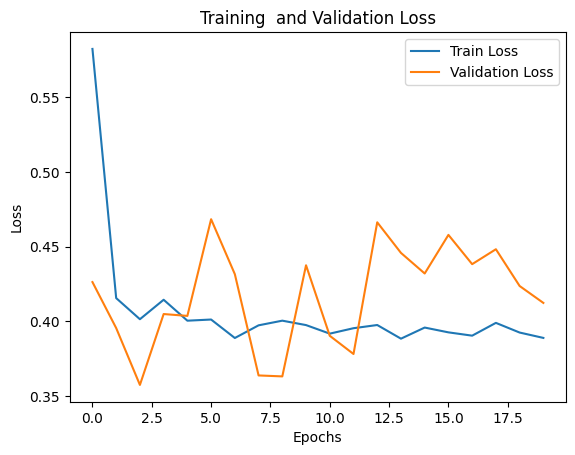

In [ ]:
class SubtleModel(nn.Module):
    def __init__(self, fe_dim, bgv_dim):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Linear(fe_dim, 8), nn.ReLU(),
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(), 
            nn.Linear(8, bgv_dim), 
        )

    def forward(self, data):
        fe = data.fe
        out = self.seq(fe)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = SubtleModel(1, 1).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
# loss_fn = LogCoshLoss()
# loss_fn = RelativeWeightedLoss()
loss_fn = nn.MSELoss()
EPOCHS = 20

# TRAIN AND VALIDATE MODEL

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    t_loss = train(model1, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model1, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model1, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')


# VISUALIZE METRICS

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()


In [33]:
class GNNModel1(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()
        # For the edges
        
        # self.edge_nn = nn.Sequential(nn.Linear(edge_dim, 64),nn.ReLU(),nn.Linear(64, node_dim * hidden_dim))

        # self.conv0 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')
        self.normalize = nn.BatchNorm1d(hidden_dim)
        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
        
        self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)
        self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)

        # =============
        # Global attributes
        self.global_embed = nn.Linear(u_dim, embed_dim)

        # ================
        # Embedding
        self.defect_embed = nn.Embedding(119, 16, max_norm=1) 
        self.pad_embed = nn.Parameter(torch.randn(16))

        # ===============
        # Combine everything

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, ids, ratios = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
            data.ids,
            data.ratios
        )

        x = F.relu(self.normalize(self.conv0(x, edge_index, edge_attr)))
        x = F.relu(self.normalize(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.normalize(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.normalize(self.conv3(x, edge_index, edge_attr)))

        x = global_mean_pool(x, batch)

        u = self.global_embed(u)

        out_emb = self.defect_embed(ids)
        # weighted_emb = out_emb * ratios.unsqueeze(1)

        if out_emb.shape[0] == 2:
            # Add padding
            to_add = self.pad_embed.unsqueeze(0) # .repeat(1, 1)
            
            out_emb = torch.cat([out_emb, to_add], dim=0)

        out_emb = out_emb.flatten().unsqueeze(0)

        x = torch.cat([x, u], dim=1)
        # x = torch.cat([x,out_emb], dim=1)

        the_return = self.fc(x)
        return the_return

# PARAMETERIZE THE MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = GNNModel1().to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = nn.MSELoss()
# loss_fn = LogCoshLoss()
# loss_fn = RelativeWeightedLoss()
EPOCHS = 20

# TRAIN AND VALIDATE MODEL

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    t_loss = train(model1, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model1, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model1, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')


# VISUALIZE METRICS

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

  0%|          | 0/11886 [00:00<?, ?it/s]

Epoch 001, Train Loss: 0.1533, Val Loss: 0.6466


Epoch 002, Train Loss: nan, Val Loss: nan


KeyboardInterrupt: 

/tmp/ipykernel_930590/3877983932.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


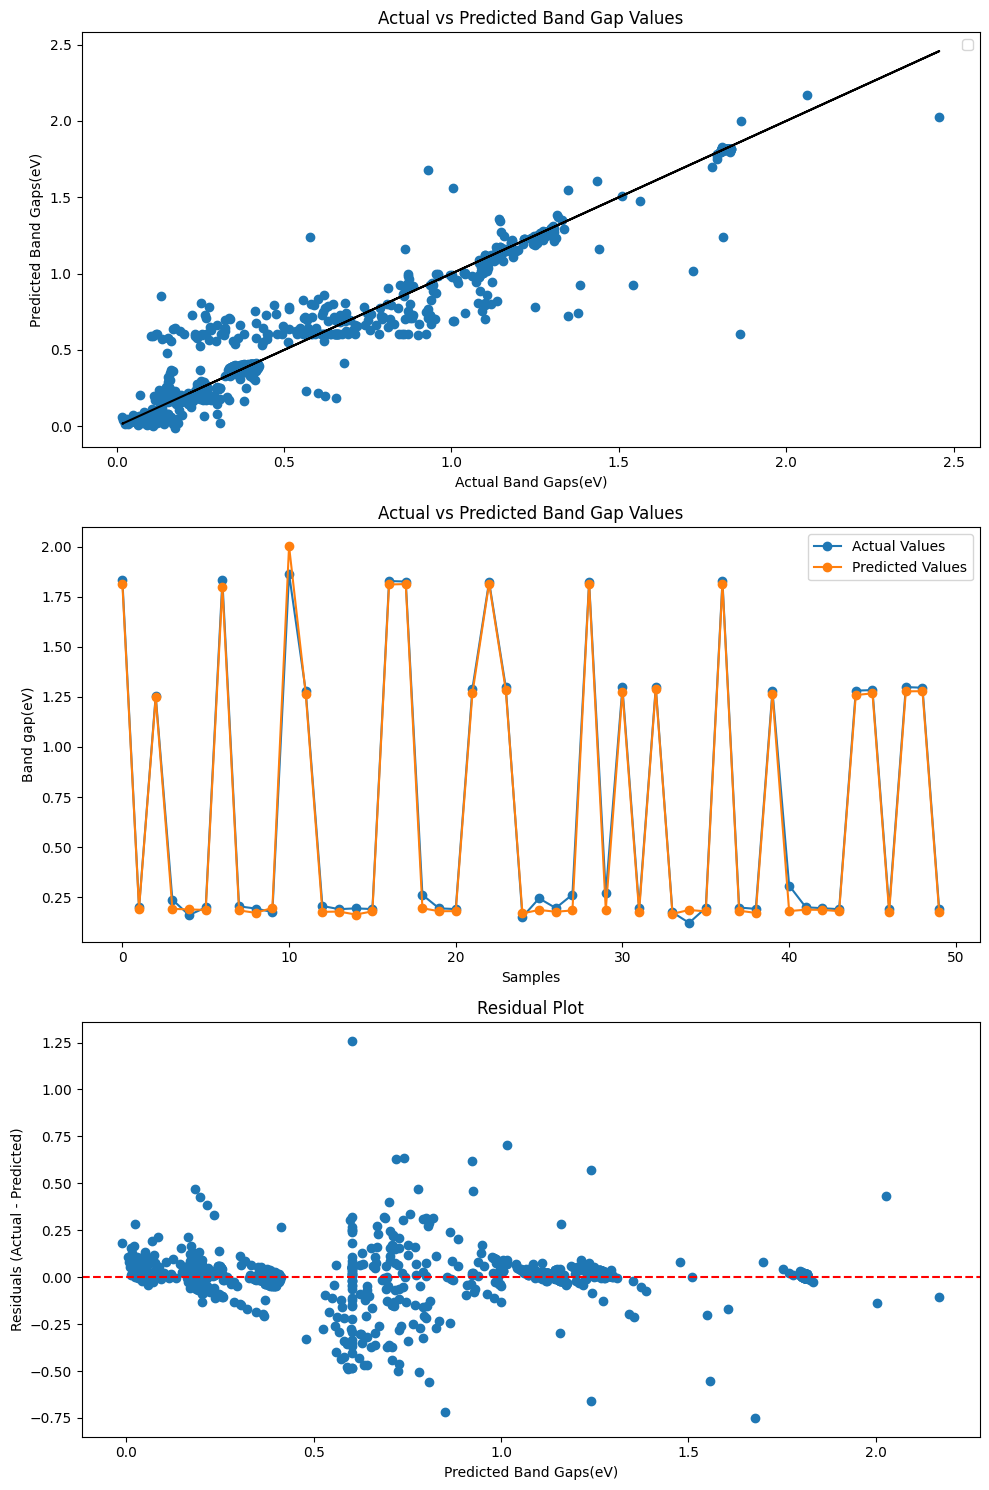

In [ ]:
# Make Predictions
predicted, the_target = predict(model1, test_loader,device, visualize=True)

# ERROR ANALYSIS

mae = mean_absolute_error(the_target, predicted)
mse = mean_squared_error(the_target, predicted)
r2 = r2_score(the_target, predicted)

print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r2:.4f}')


In [ ]:
# Save the model
path_file = "Final_Dataset/gnn models/GNNModel1.pth"
torch.save(model1.state_dict(), path_file)

## Model 2

In [ ]:
class GNNModel2(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()

        # For the edges
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, node_dim * hidden_dim)
        )

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        # self.conv1 = CGConv(hidden_dim, hidden_dim, aggr='mean')
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        the_return = self.fc(x)
        return the_return


train_losses = []
val_losses = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2 = GNNModel2().to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = LogCoshLoss()
EPOCHS = 20

for epoch in range(1, EPOCHS+1):
    t_loss = train(model2, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model2, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model2, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')

# Visualize metrics
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Save the model
# path_file = "Final_Dataset/gnn models/GNNModel2.pth"
# torch.save(model2.state_dict(), path_file)

## Model 3

In [ ]:
class GNNModel3(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, global_dim=U_DIM):
        super().__init__()

        # Edge network for NNConv: maps each edge_attr to a weight matrix
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_dim * hidden_dim),
        )

        # First message-passing layer
        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_mlp, aggr='mean')

        # Second message-passing layer using CGConv
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')
        # self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean')

        # Embed the graph-level global features
        self.global_embed = nn.Linear(global_dim, embed_dim)

        # Final MLP head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Dropout(0.2),
            # NO ReLU here - allow both positive and negative outputs
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        # x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)
        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        return self.fc(x)


train_losses = []
val_losses = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model3 = GNNModel3().to(device)
optimizer = torch.optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = LogCoshLoss()
EPOCHS = 20

for epoch in range(1, EPOCHS+1):
    t_loss = train(model3, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model3, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model3, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')

# Visualize metrics
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Save the model
# path_file = "Final_Dataset/gnn models/GNNModel3.pth"
# torch.save(model3.state_dict(), path_file)